# eduPIC: Porównanie Implementacji (C++, Go, Python)

In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import math

In [42]:
# Ścieżki do folderów z danymi RECORD (zawierających pełną diagnostykę)
paths = {
    "C++ Baseline": "../experiments/1-baseline/EXP_STAT-val/edupic_data/",
    "C++ Null-collision": "../experiments/2-null-collision/EXP_STAT-val/edupic_data/",


    # "C++ (Reference)": "../plots/hpc_logs/legit_check/C_STAT/edupic_data/",

    # "C++ OMP": "../plots/hpc_logs/legit_check/C_OMP_STAT/edupic_data/",

    # "Go Channels": "../plots/hpc_logs/legit_check/CHANNELS_STAT/edupic_data/",
    # "Go Chunking": "../plots/hpc_logs/legit_check/CHUNKING_STAT/edupic_data/",
    # "Go Chunking Optimized": "../plots/hpc_logs/legit_check/OPTIMIZED_STAT/edupic_data/"
}

## 1. Zbieżność (Convergence History)
Porównanie liczby supercząstek elektronów w funkcji cykli RF. Pozwala ocenić, czy symulacje osiągają stan stacjonarny w tym samym czasie i na tym samym poziomie.

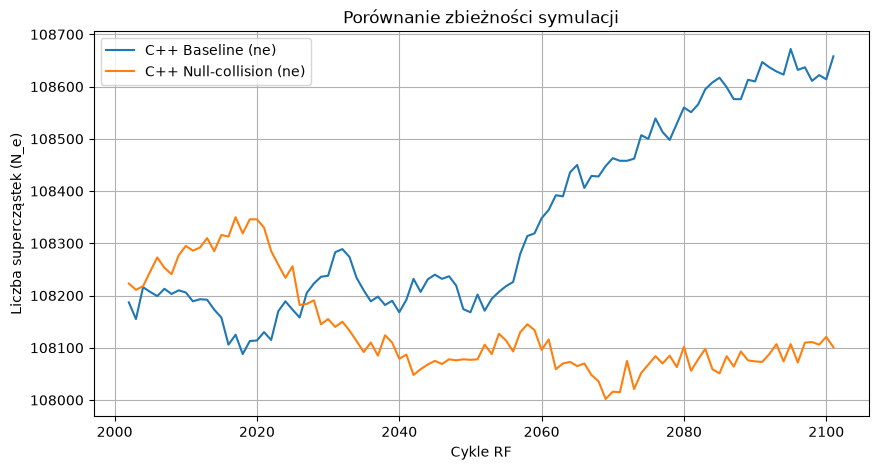

In [43]:
plt.figure(figsize=(10, 5))
for name, path in paths.items():
    conv_file = path + "conv.dat"
    if os.path.exists(conv_file):
        try:
            data = np.loadtxt(conv_file)
            if len(data.shape) > 1 and data.shape[0] > 0:
                plt.plot(data[:, 0], data[:, 1], label=f"{name} (ne)")
        except Exception as e:
            print(f"Błąd wczytywania {conv_file}: {e}")

plt.xlabel("Cykle RF")
plt.ylabel("Liczba supercząstek (N_e)")
plt.title("Porównanie zbieżności symulacji")
plt.legend()
plt.grid(True)
plt.show()

## 2. Profile Gęstości Plazmy (Plasma Density Profiles)
Profile gęstości elektronów ($n_e$) oraz jonów ($n_i$) uśrednione w czasie, przedstawione wzdłuż szczeliny wyładowczej $L = 25\text{ mm}$.

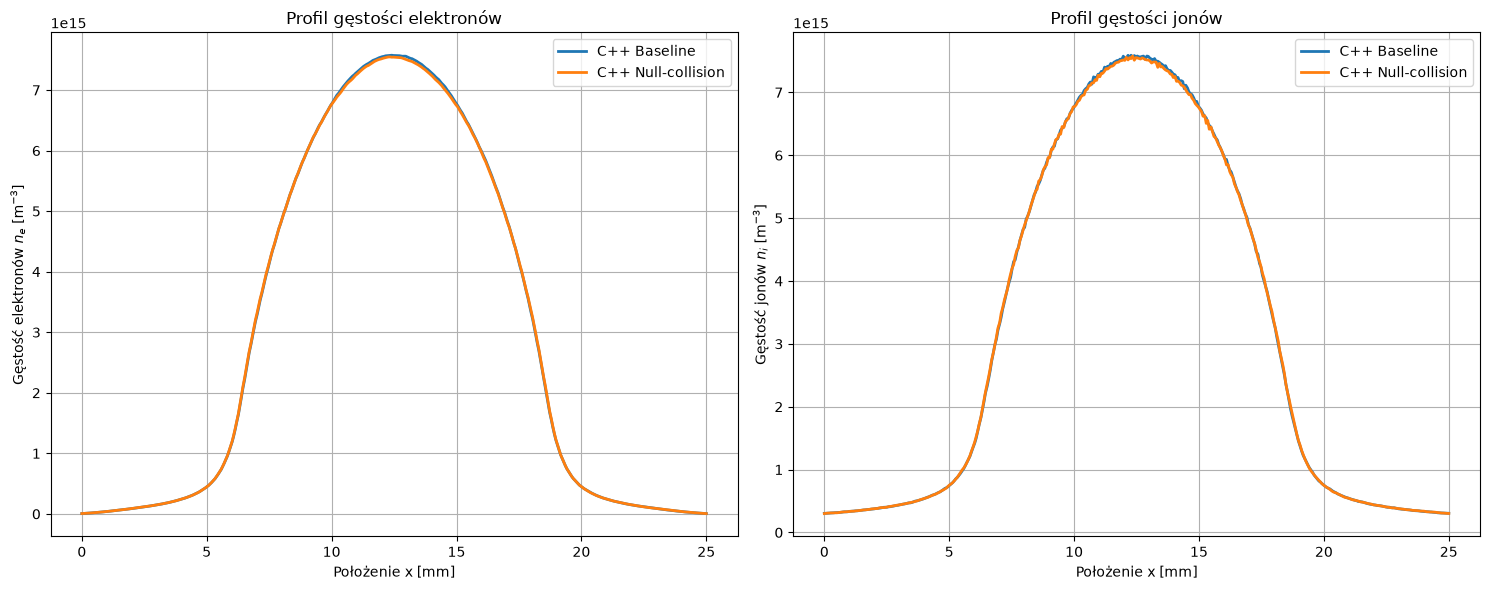

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for name, path in paths.items():
    density_file = path + "density.dat"
    if os.path.exists(density_file):
        try:
            data = np.loadtxt(density_file)
            x = data[:, 0] * 1000  # m -> mm
            ne = data[:, 1]
            ni = data[:, 2]
            
            # Zastosowanie stylów linii do rozróżnienia nakładających się wykresów
            style = "-"
            if "Go" in name: style = "--"
            elif "NumPy" in name: style = ":"
            elif "Numba" in name: style = "-."
            
            axes[0].plot(x, ne, style, label=name, linewidth=2)
            axes[1].plot(x, ni, style, label=name, linewidth=2)
        except Exception as e:
            print(f"Błąd wczytywania {density_file}: {e}")

axes[0].set_xlabel("Położenie x [mm]")
axes[0].set_ylabel("Gęstość elektronów $n_e$ [m$^{-3}$]")
axes[0].set_title("Profil gęstości elektronów")
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel("Położenie x [mm]")
axes[1].set_ylabel("Gęstość jonów $n_i$ [m$^{-3}$]")
axes[1].set_title("Profil gęstości jonów")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 3. Funkcja Prawdopodobieństwa Energii Elektronów (EEPF)
EEPF mierzone w środkowym obszarze szczeliny ($0.45L < x < 0.55L$).

[2.5000e-02 7.5000e-02 1.2500e-01 ... 9.9875e+01 9.9925e+01 9.9975e+01]
[2.5000e-02 7.5000e-02 1.2500e-01 ... 9.9875e+01 9.9925e+01 9.9975e+01]


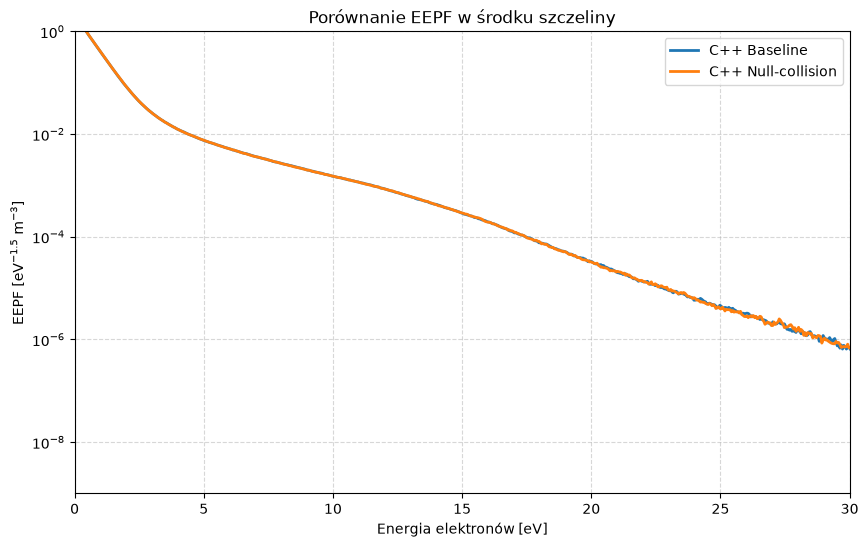

In [45]:
plt.figure(figsize=(10, 6))
for name, path in paths.items():
    eepf_file = path + "eepf.dat"
    if os.path.exists(eepf_file):
        try:
            data = np.loadtxt(eepf_file)
            energy = data[:, 0]
            f_E = data[:, 1]
            print(energy)
            
            style = "-"
            if "Go" in name: style = "--"
            elif "NumPy" in name: style = ":"
            elif "Numba" in name: style = "-."
            
            plt.semilogy(energy, f_E, style, label=name, linewidth=2)
        except Exception as e:
            print(f"Błąd wczytywania {eepf_file}: {e}")

plt.xlabel("Energia elektronów [eV]")
plt.ylabel("EEPF [eV$^{-1.5}$ m$^{-3}$]")
plt.title("Porównanie EEPF w środku szczeliny")
plt.xlim(0, 30)  # Skupiamy się na głównym przedziale energii
plt.ylim(1e-9, 1e0)  # Zakres skali logarytmicznej
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

## 4. Rozkład Energii Strumienia Jonów docierających do elektrod (IFED)
IFED (Ion Flux-Energy Distribution) zmierzony na elektrodzie zasilanej ($x=0$) oraz uziemionej ($x=L$).

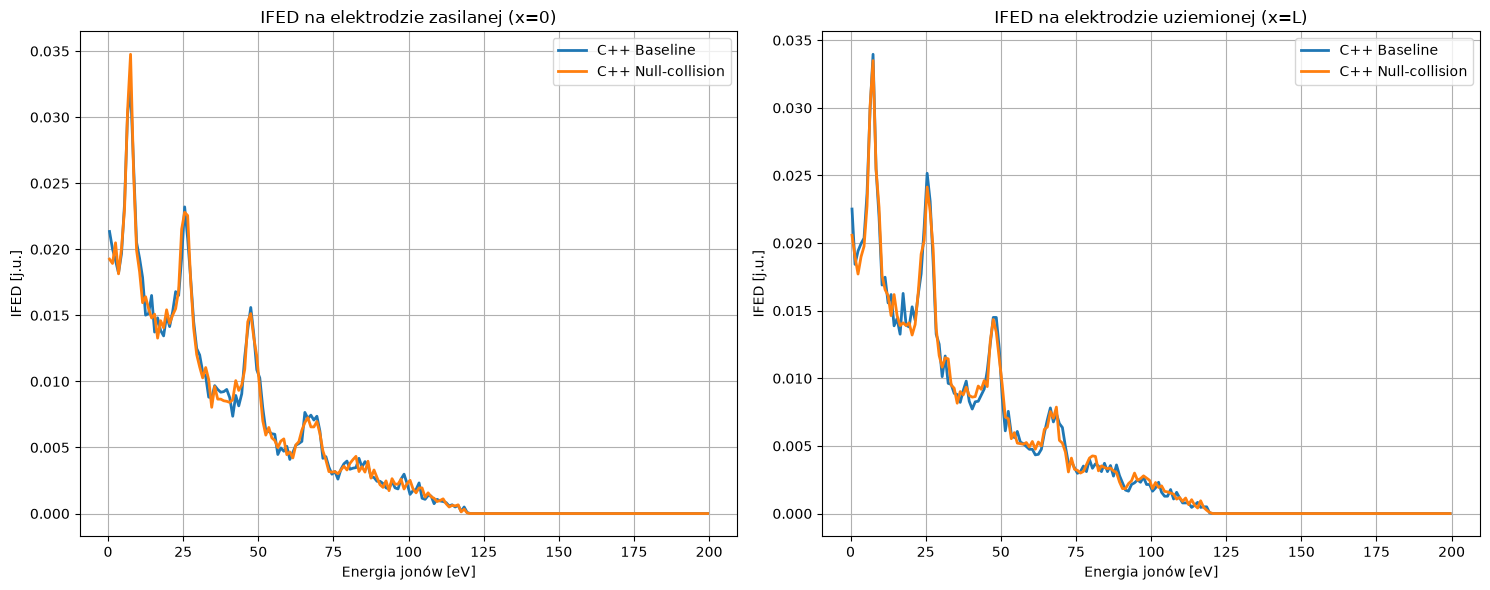

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for name, path in paths.items():
    ifed_file = path + "ifed.dat"
    if os.path.exists(ifed_file):
        try:
            data = np.loadtxt(ifed_file)
            energy = data[:, 0]
            ifed_pow = data[:, 1]
            ifed_gnd = data[:, 2]
            
            style = "-"
            if "Go" in name: style = "--"
            elif "NumPy" in name: style = ":"
            elif "Numba" in name: style = "-."
            
            axes[0].plot(energy, ifed_pow, style, label=name, linewidth=2)
            axes[1].plot(energy, ifed_gnd, style, label=name, linewidth=2)
        except Exception as e:
            print(f"Błąd wczytywania {ifed_file}: {e}")

axes[0].set_xlabel("Energia jonów [eV]")
axes[0].set_ylabel("IFED [j.u.]")
axes[0].set_title("IFED na elektrodzie zasilanej (x=0)")
axes[0].legend()
axes[0].grid(True)

axes[1].set_xlabel("Energia jonów [eV]")
axes[1].set_ylabel("IFED [j.u.]")
axes[1].set_title("IFED na elektrodzie uziemionej (x=L)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Spacjoczasowe profile pola elektrycznego i potencjału (2D Spatio-Temporal Diagnostics)
Pokazuje ewolucję potencjału w czasie (wewnątrz jednego cyklu radiowego RF) i przestrzeni (szerokość szczeliny).

{'C++ Baseline': '../experiments/1-baseline/EXP_STAT-val/edupic_data/', 'C++ Null-collision': '../experiments/2-null-collision/EXP_STAT-val/edupic_data/'}


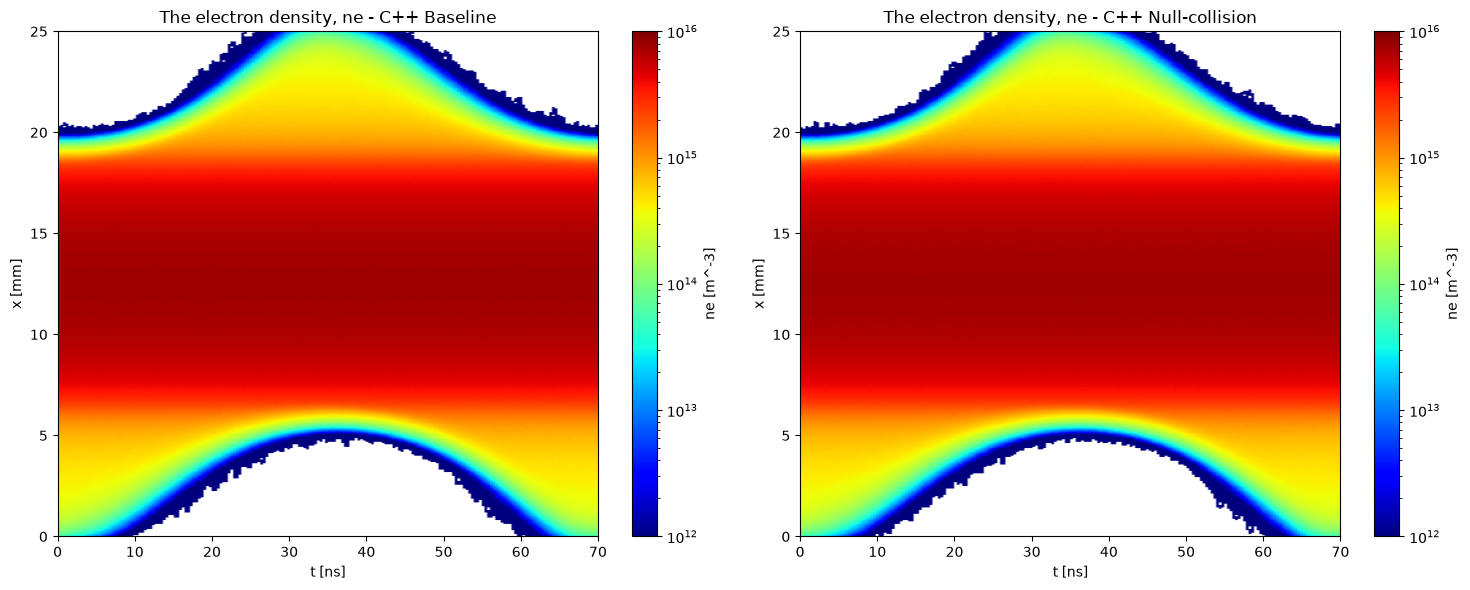

In [47]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
print(active_paths)
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()


for i, (name, path) in enumerate(active_paths.items()):
    ne_xt_file = path + "ne_xt.dat"
    if os.path.exists(ne_xt_file):
        try:
            ne_xt = np.loadtxt(ne_xt_file)
            ax = ax_list[i]
            
            im = ax.imshow(ne_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet',
                           norm=LogNorm(vmin=1e12, vmax=1e16))
            fig.colorbar(im, ax=ax, label='ne [m^-3]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The electron density, ne - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {ne_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

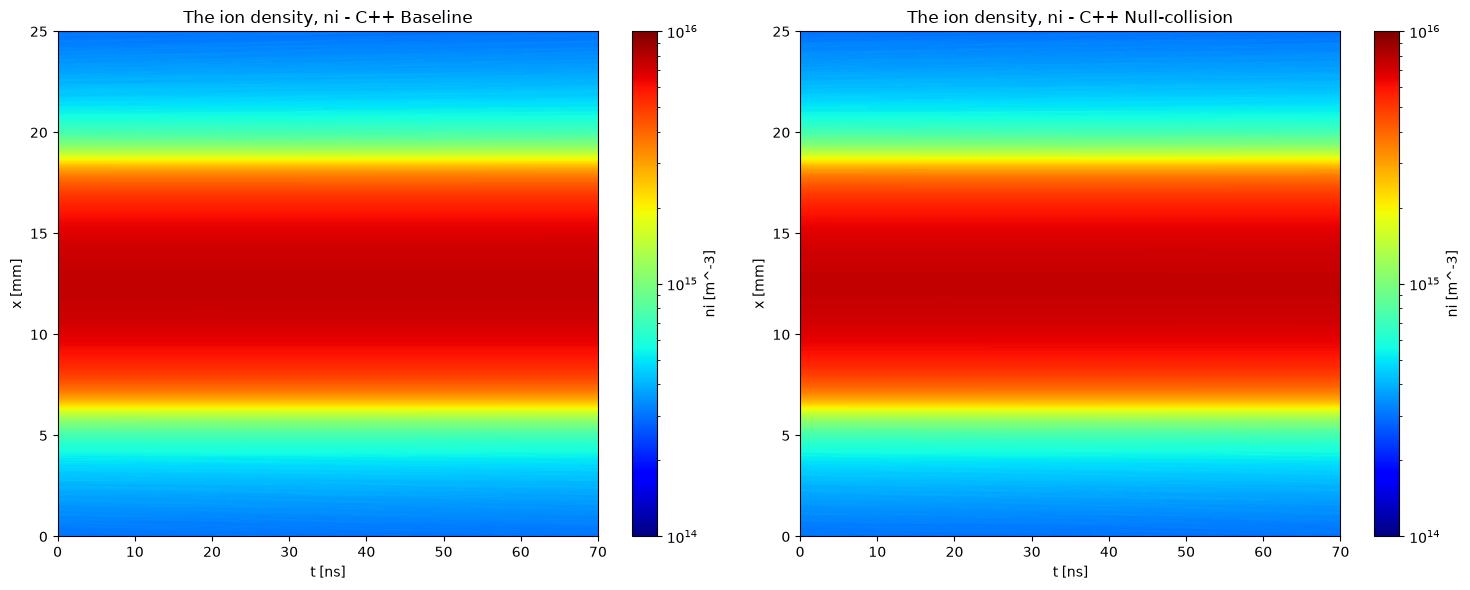

In [48]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    ni_xt_file = path + "ni_xt.dat"
    if os.path.exists(ni_xt_file):
        try:
            ni_xt = np.loadtxt(ni_xt_file)
            ax = ax_list[i]
            
            im = ax.imshow(ni_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet',
                           norm=LogNorm(vmin=1e14, vmax=1e16))
            fig.colorbar(im, ax=ax, label='ni [m^-3]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The ion density, ni - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {ni_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

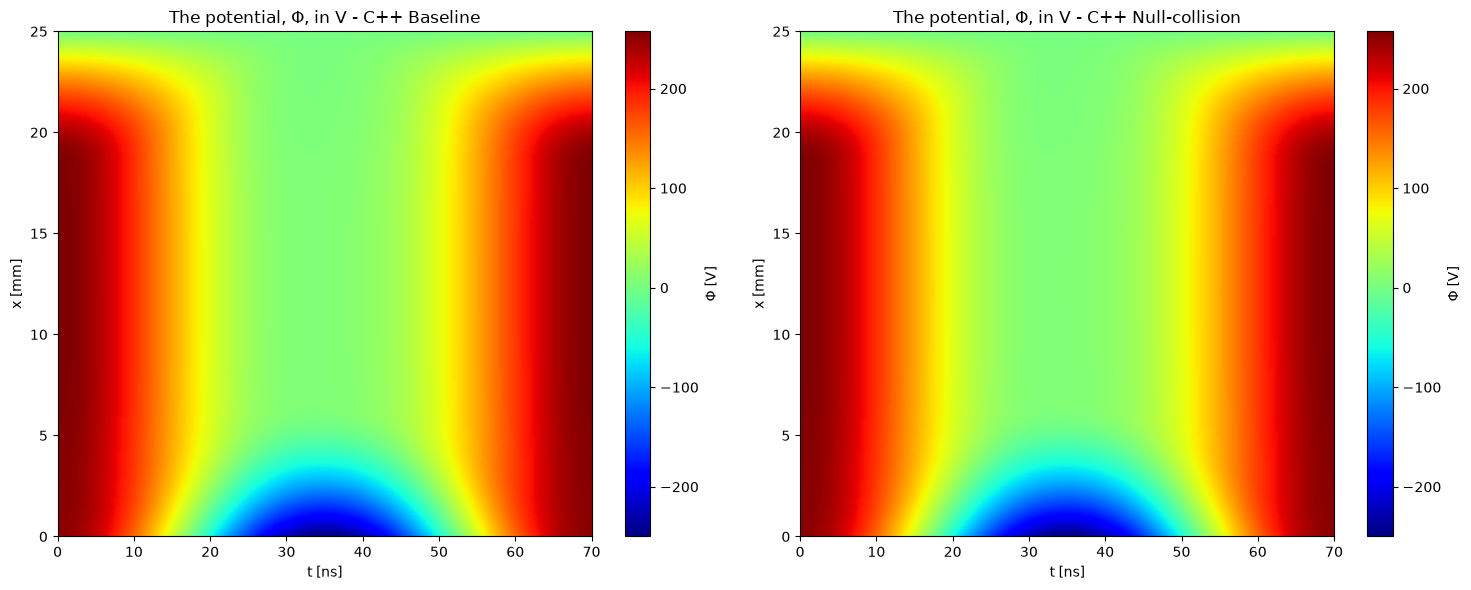

In [49]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    pot_xt_file = path + "pot_xt.dat"
    if os.path.exists(pot_xt_file):
        try:
            pot_xt = np.loadtxt(pot_xt_file)
            ax = ax_list[i]
            
            im = ax.imshow(pot_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet')
            fig.colorbar(im, ax=ax, label='Φ [V]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The potential, Φ, in V - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {pot_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

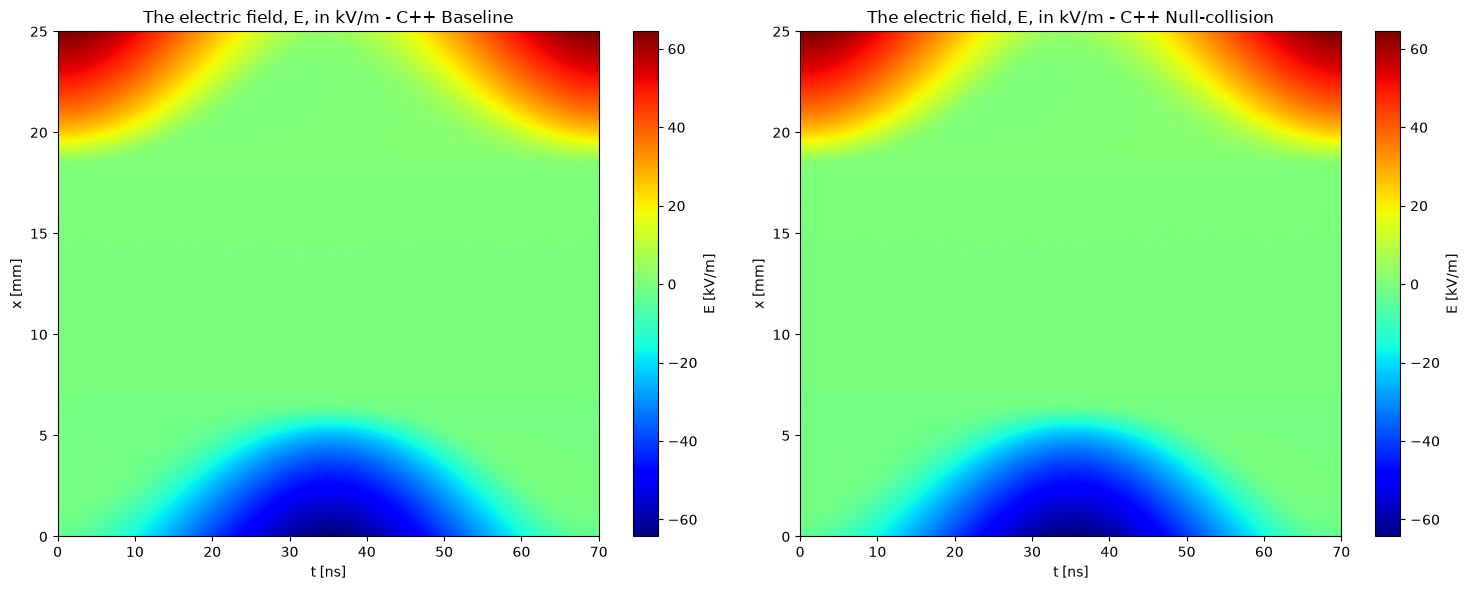

In [50]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    efield_xt_file = path + "efield_xt.dat"
    if os.path.exists(efield_xt_file):
        try:
            efield_xt = np.loadtxt(efield_xt_file)
            efield_xt *= 0.001
            ax = ax_list[i]
            
            im = ax.imshow(efield_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet')
            fig.colorbar(im, ax=ax, label='E [kV/m]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The electric field, E, in kV/m - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {efield_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

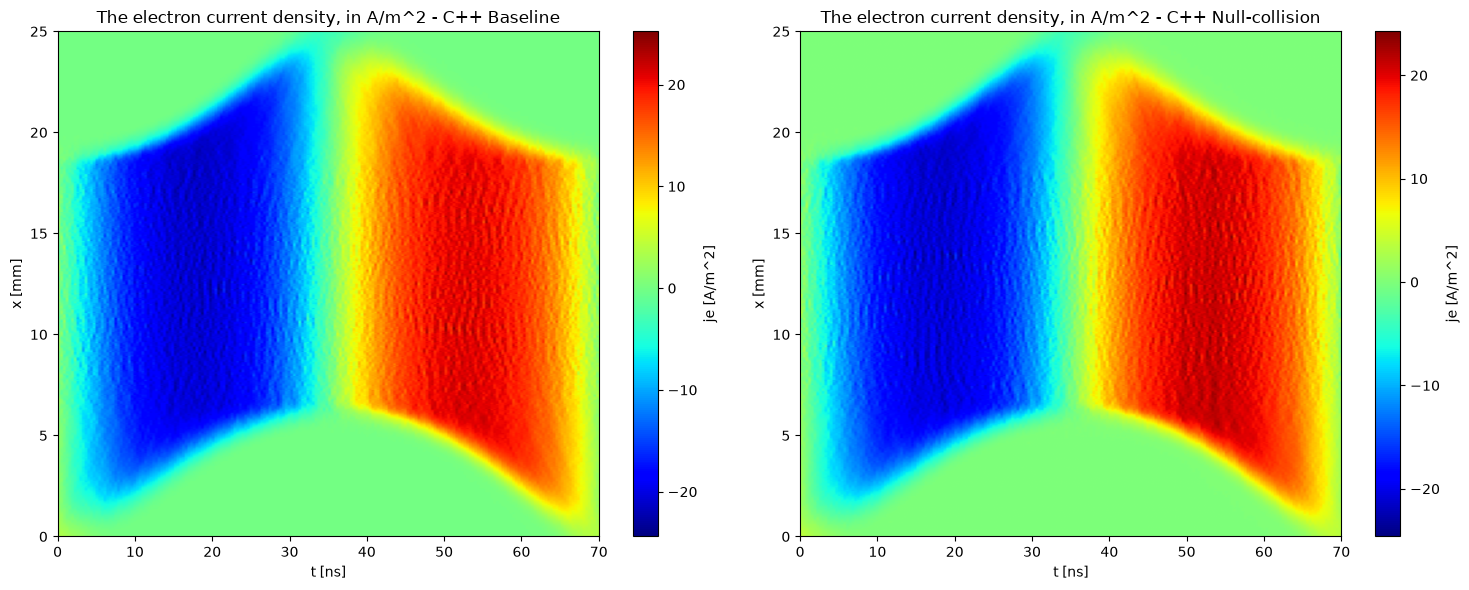

In [51]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    je_xt_file = path + "je_xt.dat"
    if os.path.exists(je_xt_file):
        try:
            je_xt = np.loadtxt(je_xt_file)
            ax = ax_list[i]
            
            im = ax.imshow(je_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet')
            fig.colorbar(im, ax=ax, label='je [A/m^2]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The electron current density, in A/m^2 - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {je_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

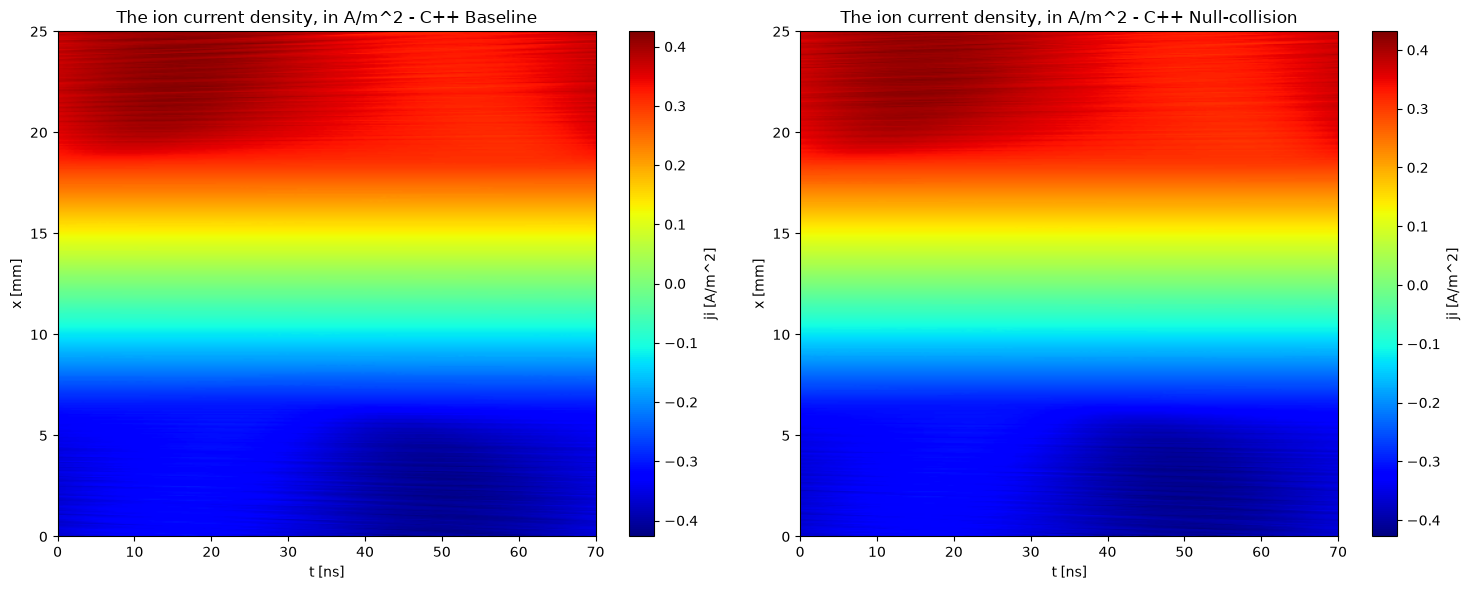

In [52]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    ji_xt_file = path + "ji_xt.dat"
    if os.path.exists(ji_xt_file):
        try:
            ji_xt = np.loadtxt(ji_xt_file)
            ax = ax_list[i]
            
            im = ax.imshow(ji_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet')
            fig.colorbar(im, ax=ax, label='ji [A/m^2]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The ion current density, in A/m^2 - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {ji_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

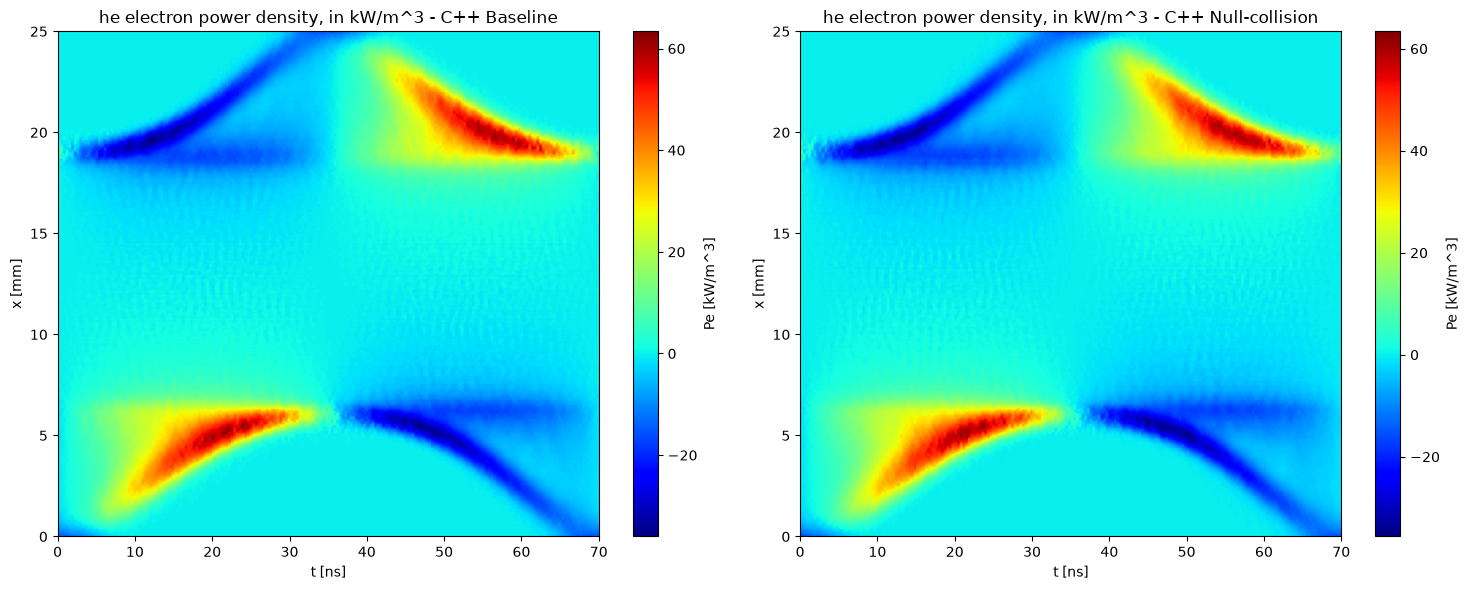

In [53]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    powere_xt_file = path + "powere_xt.dat"
    if os.path.exists(powere_xt_file):
        try:
            powere_xt = np.loadtxt(powere_xt_file)
            powere_xt *= 0.001

            ax = ax_list[i]
            
            im = ax.imshow(powere_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet')
            fig.colorbar(im, ax=ax, label='Pe [kW/m^3]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'he electron power density, in kW/m^3 - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {powere_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

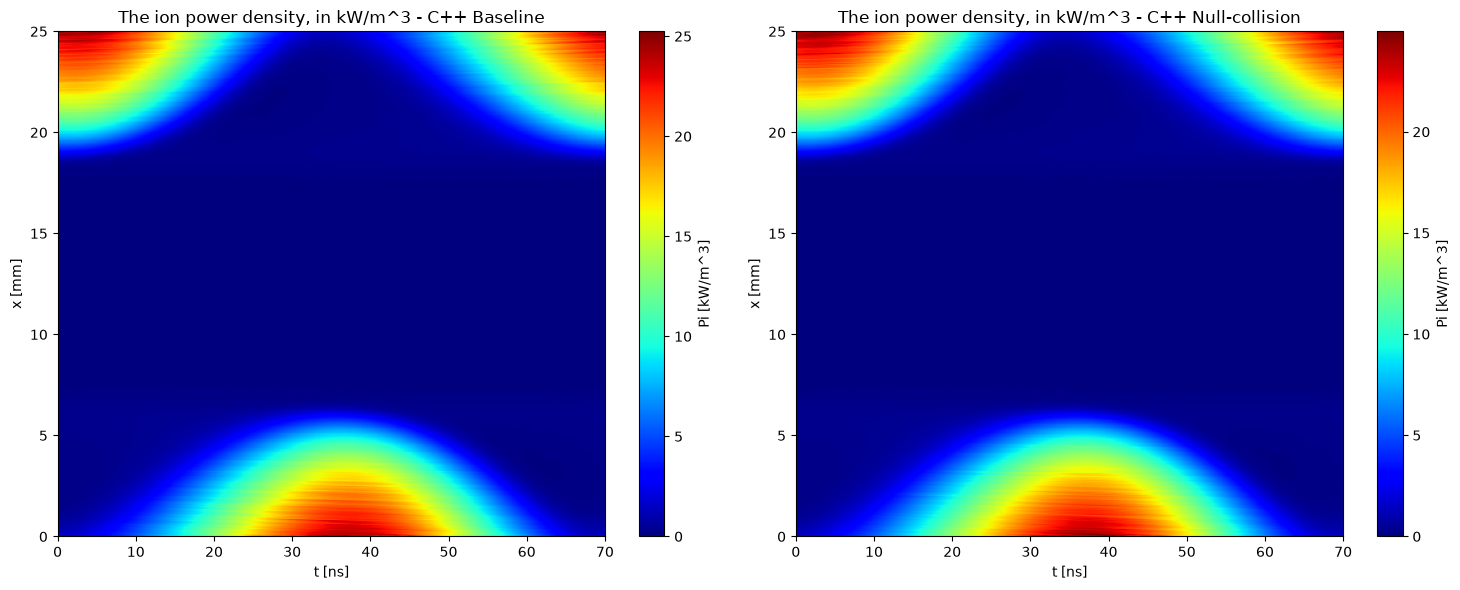

In [54]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    poweri_xt_file = path + "poweri_xt.dat"
    if os.path.exists(poweri_xt_file):
        try:
            poweri_xt = np.loadtxt(poweri_xt_file)
            poweri_xt *= 0.001
            ax = ax_list[i]
            
            im = ax.imshow(poweri_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet')
            fig.colorbar(im, ax=ax, label='Pi [kW/m^3]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The ion power density, in kW/m^3 - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {poweri_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

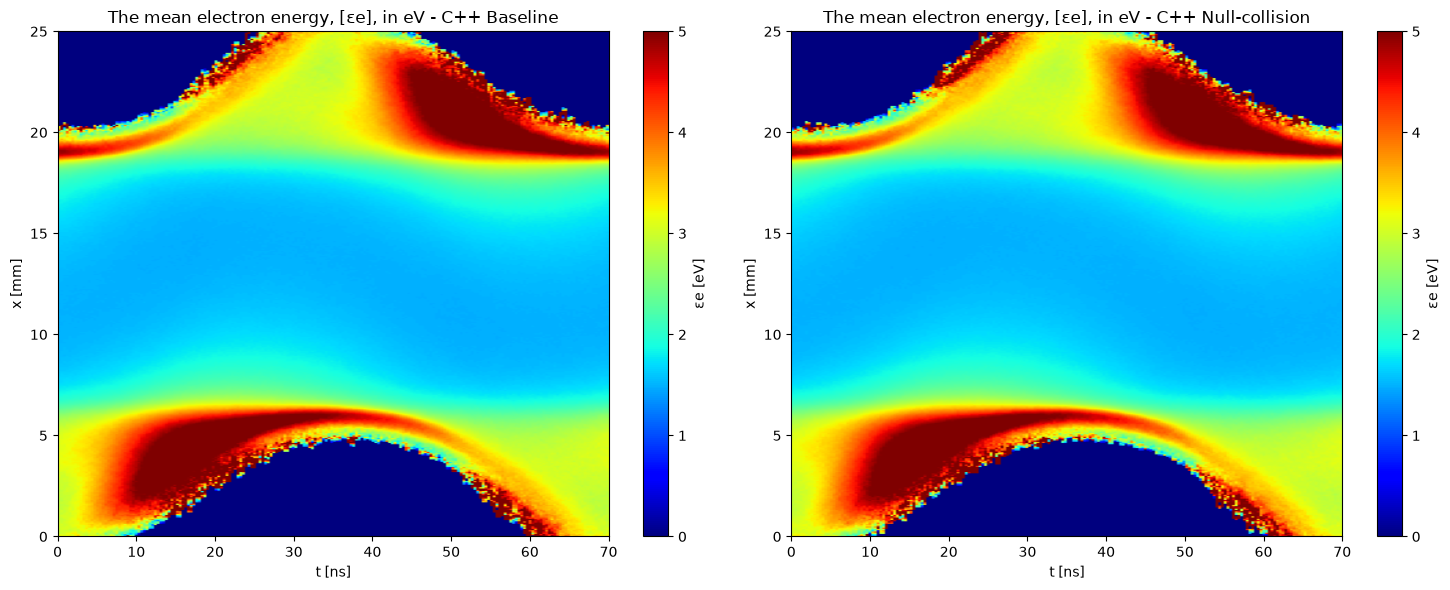

In [55]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    meanee_xt_file = path + "meanee_xt.dat"
    if os.path.exists(meanee_xt_file):
        try:
            meanee_xt = np.loadtxt(meanee_xt_file)
            ax = ax_list[i]
            
            im = ax.imshow(meanee_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet',
                           vmin=0.0, vmax=5.0)
            fig.colorbar(im, ax=ax, label='εe [eV]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The mean electron energy, [εe], in eV - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {meanee_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

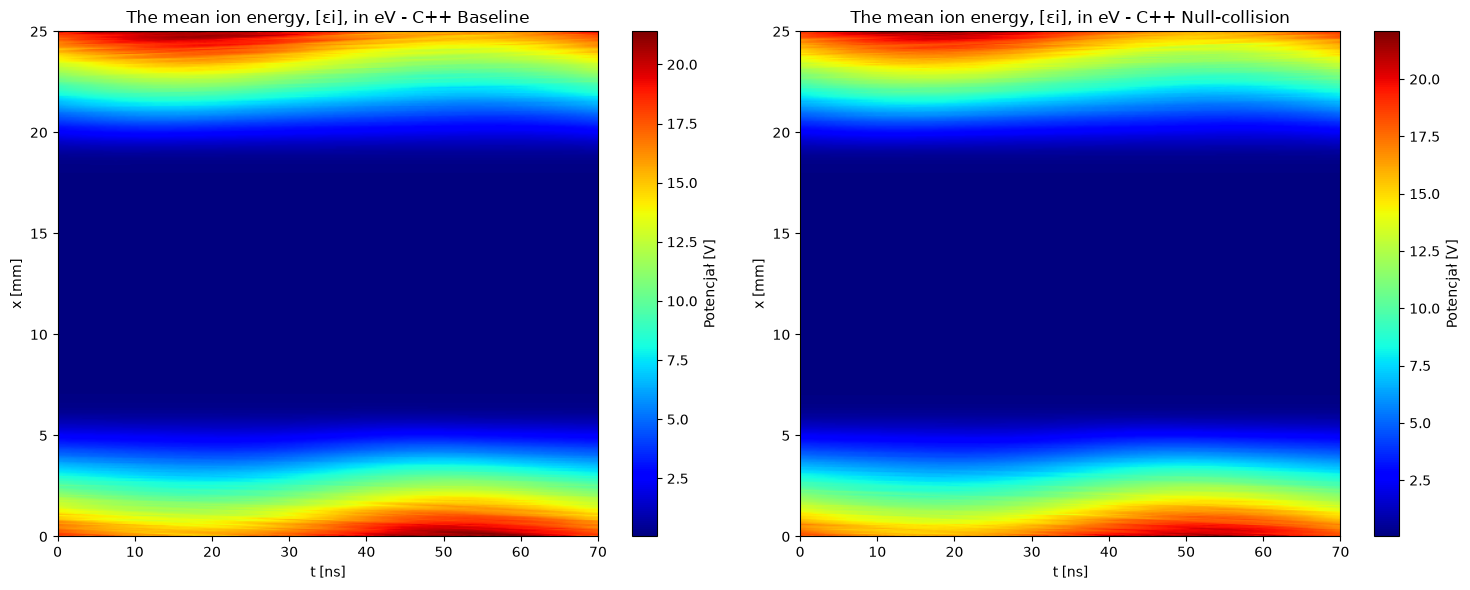

In [56]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    meanei_xt_file = path + "meanei_xt.dat"
    if os.path.exists(meanei_xt_file):
        try:
            meanei_xt = np.loadtxt(meanei_xt_file)
            ax = ax_list[i]
            
            im = ax.imshow(meanei_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet')
            fig.colorbar(im, ax=ax, label='Potencjał [V]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The mean ion energy, [εi], in eV - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {meanei_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()

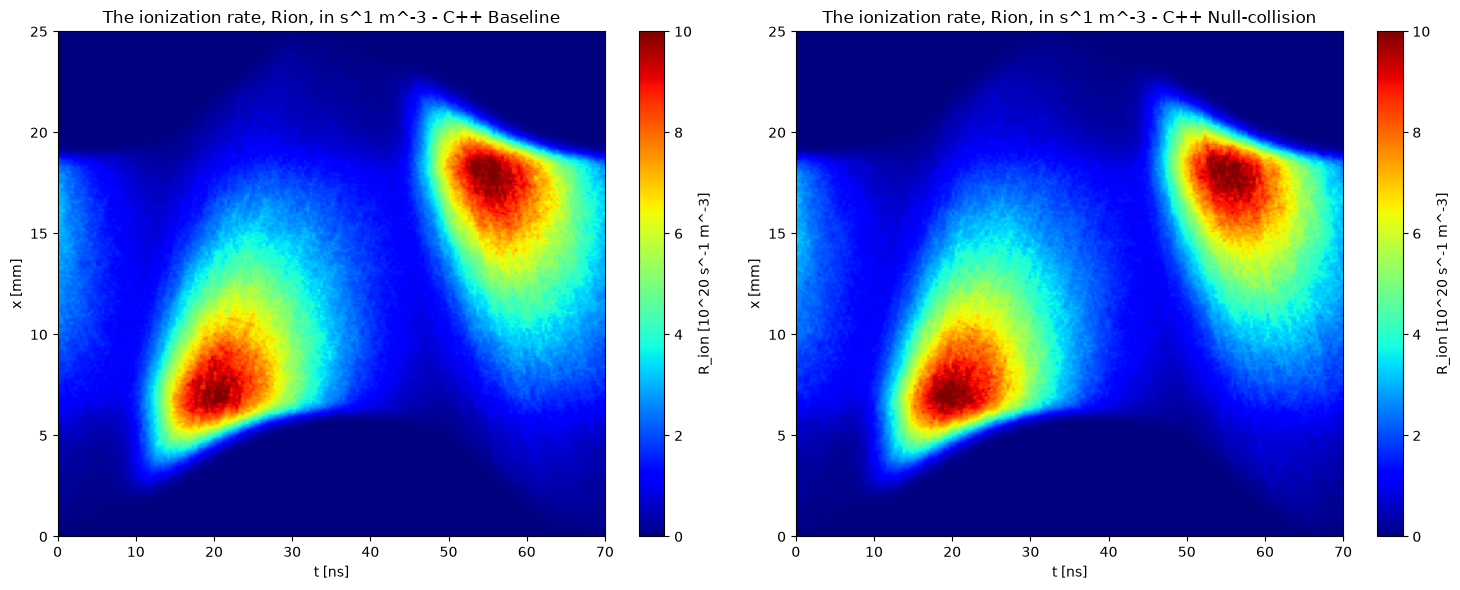

In [57]:
active_paths = {k: v for k, v in paths.items() if k != "Python (Native)"}
n_plots = len(active_paths)
cols = 2
rows = math.ceil(n_plots/cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 6* rows))
ax_list = axes.flatten()

for i, (name, path) in enumerate(active_paths.items()):
    ioniz_xt_file = path + "ioniz_xt.dat"
    if os.path.exists(ioniz_xt_file):
        try:
            ioniz_xt = np.loadtxt(ioniz_xt_file)
            ioniz_xt /= 1e20
            ax = ax_list[i]
            
            im = ax.imshow(ioniz_xt, aspect='auto', origin='lower', 
                           extent=[0, 70, 0, 25], cmap='jet',
                           vmin=0.0, vmax=10.0)
            fig.colorbar(im, ax=ax, label='R_ion [10^20 s^-1 m^-3]')
            ax.set_xlabel('t [ns]')
            ax.set_ylabel('x [mm]')
            ax.set_title(f'The ionization rate, Rion, in s^1 m^-3 - {name}')
        except Exception as e:
            print(f"Błąd wczytywania {ioniz_xt_file}: {e}")

for j in range(n_plots, len(ax_list)):
    fig.delaxes(ax_list[j])

plt.tight_layout()
plt.show()